In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 2

Construct a neural network with one hidden layer to solve the XOR gate problem. Experiment with hidden layer sizes of 2, 3, and 4 neurons (using sigmoid activation) and compare training accuracy. Explain why a single-layer network fails for XOR and how hidden layer size impacts the network's ability to learn this non-linear pattern.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def accuracy(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(float)
    return (y_pred == y_true).mean()

def bce_loss(y_true, y_prob, eps=1e-8):
    return -np.mean(y_true * np.log(y_prob + eps) + (1 - y_true) * np.log(1 - y_prob + eps))

Assignment 2 - XOR results
hidden=2: acc=0.75, probs=[0.3492 0.4714 0.874  0.342 ]
hidden=3: acc=1.00, probs=[0.062  0.9491 0.9244 0.0794]
hidden=4: acc=0.75, probs=[0.2673 0.8829 0.4315 0.4335]


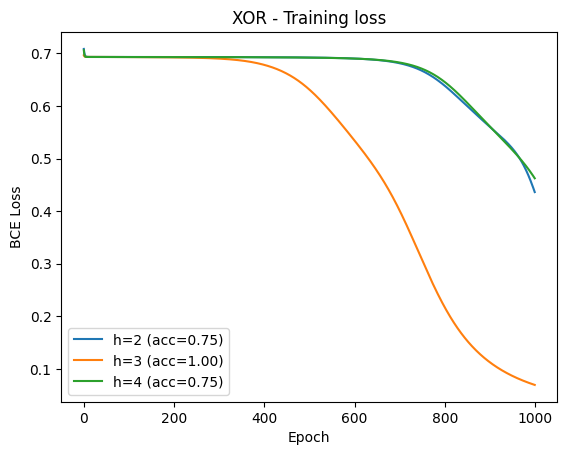

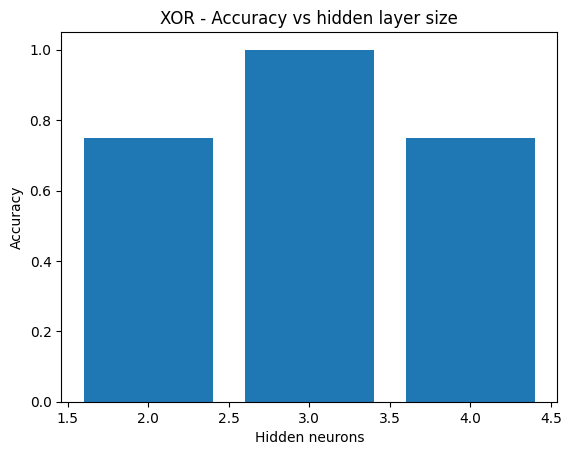

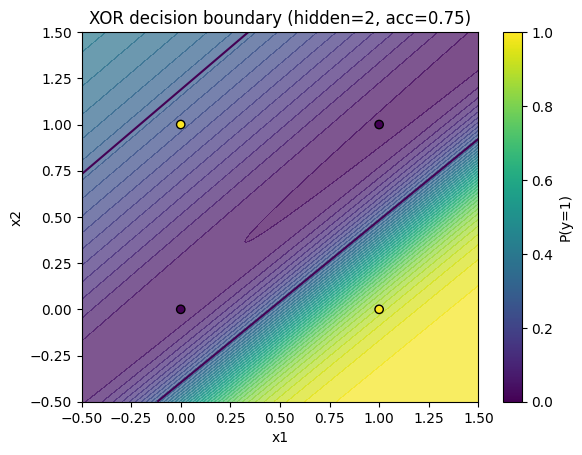

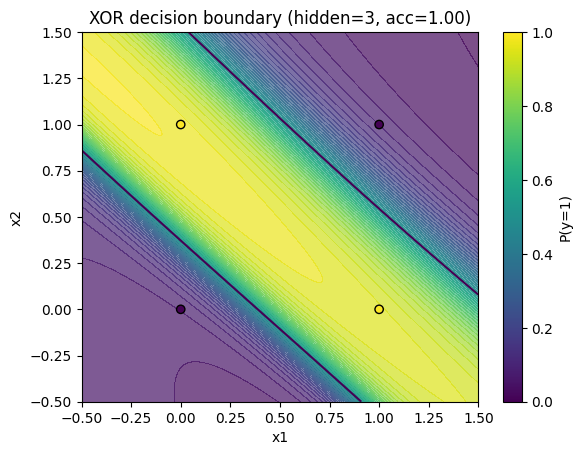

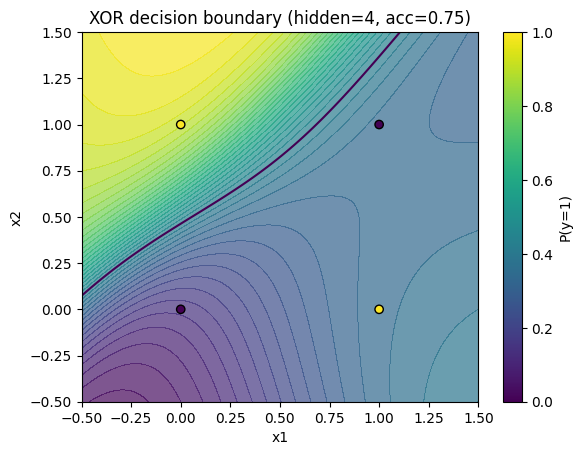

In [12]:
def make_xor():
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)
    y = np.array([0, 1, 1, 0], dtype=float).reshape(-1, 1)
    return X, y

# -------------------------
# Train (2 - h - 1) MLP for XOR
# Hidden: sigmoid
# Output: sigmoid
# -------------------------
def train_xor(hidden_size, lr=1.0, epochs=5000, seed=1):
    rng = np.random.default_rng(seed)
    X, y = make_xor()

    W1 = rng.normal(0, 1, size=(2, hidden_size)) * 0.5
    b1 = np.zeros(hidden_size)

    W2 = rng.normal(0, 1, size=(hidden_size, 1)) * 0.5
    b2 = np.zeros(1)

    losses = []

    for _ in range(epochs):
        # forward
        z1 = X @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        # loss
        losses.append(bce_loss(y, a2))

        # backprop (sigmoid + BCE)
        dz2 = (a2 - y) / len(X)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ W2.T
        dz1 = da1 * (a1 * (1 - a1))
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)

        # update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    y_prob = sigmoid(sigmoid(X @ W1 + b1) @ W2 + b2).ravel()
    y_true = y.ravel()
    acc = accuracy(y_true, y_prob)

    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return acc, y_prob, losses, params


# -------------------------
# Visualization 1: Loss curves
# -------------------------
def plot_loss_curves(hidden_sizes=(2, 3, 4), lr=1.0, epochs=5000, seed=1):
    plt.figure()
    for h in hidden_sizes:
        acc, y_prob, losses, _ = train_xor(hidden_size=h, lr=lr, epochs=epochs, seed=seed)
        plt.plot(losses, label=f"h={h} (acc={acc:.2f})")
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.title("XOR - Training loss")
    plt.legend()
    plt.show()


# -------------------------
# Visualization 2: Accuracy vs hidden size
# -------------------------
def plot_accuracy_bar(hidden_sizes=(2, 3, 4), lr=1.0, epochs=5000, seed=1):
    accs = []
    for h in hidden_sizes:
        acc, _, _, _ = train_xor(hidden_size=h, lr=lr, epochs=epochs, seed=seed)
        accs.append(acc)

    plt.figure()
    plt.bar(list(hidden_sizes), accs)
    plt.xlabel("Hidden neurons")
    plt.ylabel("Accuracy")
    plt.title("XOR - Accuracy vs hidden layer size")
    plt.ylim(0, 1.05)
    plt.show()


# -------------------------
# Decision boundary visualization
# -------------------------
def predict_proba(grid, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    a1 = sigmoid(grid @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)
    return a2.ravel()

def plot_decision_boundary(hidden_size, lr=1.0, epochs=5000, seed=1):
    X, y = make_xor()
    acc, _, _, params = train_xor(hidden_size=hidden_size, lr=lr, epochs=epochs, seed=seed)

    xx, yy = np.meshgrid(
        np.linspace(-0.5, 1.5, 250),
        np.linspace(-0.5, 1.5, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_proba(grid, params).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, probs, levels=50, alpha=0.7)
    plt.contour(xx, yy, probs, levels=[0.5])
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors="k")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"XOR decision boundary (hidden={hidden_size}, acc={acc:.2f})")
    plt.colorbar(label="P(y=1)")
    plt.show()

hidden_sizes = (2, 3, 4)
lr = 0.7
epochs = 1000
seed = 1

print("Assignment 2 - XOR results")
for h in hidden_sizes:
    acc, y_prob, _, _ = train_xor(hidden_size=h, lr=lr, epochs=epochs, seed=seed)
    print(f"hidden={h}: acc={acc:.2f}, probs={np.round(y_prob, 4)}")

plot_loss_curves(hidden_sizes=hidden_sizes, lr=lr, epochs=epochs, seed=seed)
plot_accuracy_bar(hidden_sizes=hidden_sizes, lr=lr, epochs=epochs, seed=seed)

for h in hidden_sizes:
    plot_decision_boundary(hidden_size=h, lr=lr, epochs=epochs, seed=seed)

XOR is not linearly separable, therefore a single-layer network cannot solve it. A hidden layer is required to construct a non-linear decision boundary. However, your results clearly show that **having a hidden layer is not sufficient by itself** - optimization and architecture size also matter.

With **2 hidden neurons**, the network reaches only **0.75 accuracy**. The loss decreases slightly but then plateaus. The decision boundary plot confirms this: the model learns something non-linear, but it still misclassifies one of the four XOR points. The probabilities reflect uncertainty, especially around the difficult cases (e.g., values around 0.34–0.47). This indicates that the model does not find a fully separating representation in 1000 epochs.

With **3 hidden neurons**, the network achieves **perfect accuracy (1.00)**. The loss curve shows a clear and sharp decrease, indicating successful optimization. The decision boundary is well-structured: it forms a clean non-linear region that correctly separates the two positive XOR points from the two negative ones. The predicted probabilities are confident (close to 0 or 1), which confirms that the network has learned a stable internal representation.

Interestingly, with **4 hidden neurons**, performance drops back to **0.75 accuracy**. Although the model has more capacity, it does not converge to the correct solution within 1000 epochs. The loss decreases but not enough to fully separate the classes. The decision boundary appears more complex but less well-aligned with the XOR structure. This suggests that additional capacity can sometimes make optimization harder, especially with a fixed learning rate and limited epochs.

Overall, these results demonstrate three important points:

1. A hidden layer enables non-linear decision boundaries, which makes XOR solvable in principle.
2. The minimal architecture (hidden = 2) is theoretically sufficient but may require better optimization settings to reach full accuracy.
3. Increasing the number of neurons increases representational capacity but does not guarantee better performance - training dynamics and hyperparameters play a critical role.

The visualizations strongly support this interpretation. The loss curves illustrate differences in convergence behavior, the accuracy chart summarizes final performance, and the decision boundaries provide the most intuitive explanation of why only the 3-neuron model successfully captures the XOR pattern under the given training conditions.